In [1]:
#Library Imports
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

#Dataset loading
iris = load_iris()

#X/y split
X = iris.data
y = iris.target

#Train/Test Split (%20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

#Feature Scaling
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

#Model Training & Benchmark Dictionary
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Linear SVM": SVC(kernel='linear', probability=True, random_state=42),
    "Kernel SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
    
}

for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test,y_pred)
    roc_auc = roc_auc_score(y_test,y_prob, multi_class='ovr')

    print(f"\nModel: {name}")
    print(f"Accuracy: % {acc*100:.2f}")
    print(f"ROC/AUC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    




Model: Logistic Regression
Accuracy: % 100.00
ROC/AUC: 1.0000
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Model: KNN
Accuracy: % 100.00
ROC/AUC: 1.0000
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Model: Linear SVM
Accuracy: % 96.67
ROC/AUC: 1.0000
Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]

Model: Kernel SVM (RBF)
Accuracy: % 100.00
ROC/AUC: 1.0000
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Model: Naive Bayes
Accuracy: % 100.00
ROC/AUC: 1.0000
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Model: Decision Tree
Accuracy: % 100.00
ROC/AUC: 1.0000
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Model: Random Forest
Accuracy: % 100.00
ROC/AUC: 1.0000
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


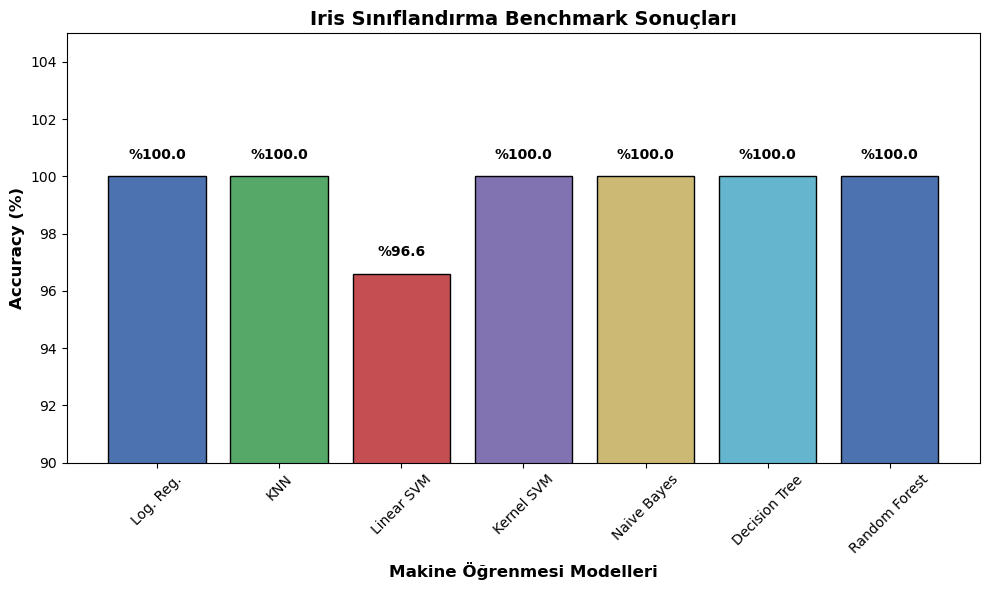

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Modeller ve elde ettiğimiz Accuracy sonuçları
modeller = ['Log. Reg.', 'KNN', 'Linear SVM', 'Kernel SVM', 'Naive Bayes', 'Decision Tree', 'Random Forest']
# Linear SVM %96.6 çıkmıştı, diğerleri %100'dü
skorlar = [100.0, 100.0, 96.6, 100.0, 100.0, 100.0, 100.0]

# Grafiğin boyutunu ayarlama
plt.figure(figsize=(10, 6))

# Bar grafiğini çizdirme (Farklı renkler atayarak şık bir görünüm elde ediyoruz)
renkler = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD', '#4C72B0']
bar_grafik = plt.bar(modeller, skorlar, color=renkler, edgecolor='black')

# Eksen ayarları
plt.ylim(90, 105) # Sadece 90 ile 105 arasını göster ki aradaki fark belli olsun
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.xlabel('Makine Öğrenmesi Modelleri', fontsize=12, fontweight='bold')
plt.title('Iris Sınıflandırma Benchmark Sonuçları', fontsize=14, fontweight='bold')
plt.xticks(rotation=45) # İsimler uzun olduğu için yatay eksendeki yazıları 45 derece eğiyoruz

# Barların tepesine tam değerleri yazdırma
for bar in bar_grafik:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'%{yval}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

# İŞTE EN ÖNEMLİ KISIM: Grafiği klasöre PNG olarak kaydetme
plt.savefig('results_graph.png', dpi=300)

# Grafiği ekranda göster
plt.show()